# Skin-Lesion Image Classification

### EfficientNetB0 — Google Colab

This is a simple educational image-classification project using the HAM10000 dataset.

**Pipeline:**

Input Image → Pre-trained EfficientNetB0 → Inference → Processing → Output

**Important:** This project is for educational purposes only. It is **not a clinical diagnosis** and should not be used for medical decisions.

## 1. Install the libraries

Run this cell first.

In [ ]:
!pip install -q kagglehub tensorflow pandas matplotlib scikit-learn pillow

## 2. Download HAM10000 directly from Kaggle

This uses `kagglehub`, so you do not need to manually upload `kaggle.json`.

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "kmader/skin-cancer-mnist-ham10000"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset path: /kaggle/input/skin-cancer-mnist-ham10000


## 3. Import libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 4. Load the metadata

The metadata file is inside the Kaggle dataset folder.

In [ ]:
metadata_file = os.path.join(
    path,
    "HAM10000_metadata.csv"
)

metadata = pd.read_csv(metadata_file)

print("Metadata shape:", metadata.shape)
metadata.head()

Metadata shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## 5. Find the image files

The dataset can contain the images inside subfolders, so we search all folders.

In [ ]:
image_files = {}

for root, folders, files in os.walk(path):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_id = os.path.splitext(file)[0]
            image_files[image_id] = os.path.join(root, file)

print("Images found:", len(image_files))

metadata["image_path"] = metadata["image_id"].map(image_files)

print("Images matched:", metadata["image_path"].notna().sum())

metadata = metadata.dropna(
    subset=["image_path"]
).copy()

print("Final number of images:", len(metadata))
print("Classes:")
print(metadata["dx"].value_counts())

Images found: 10015
Images matched: 10015
Final number of images: 10015
Classes:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


## 6. Display some images

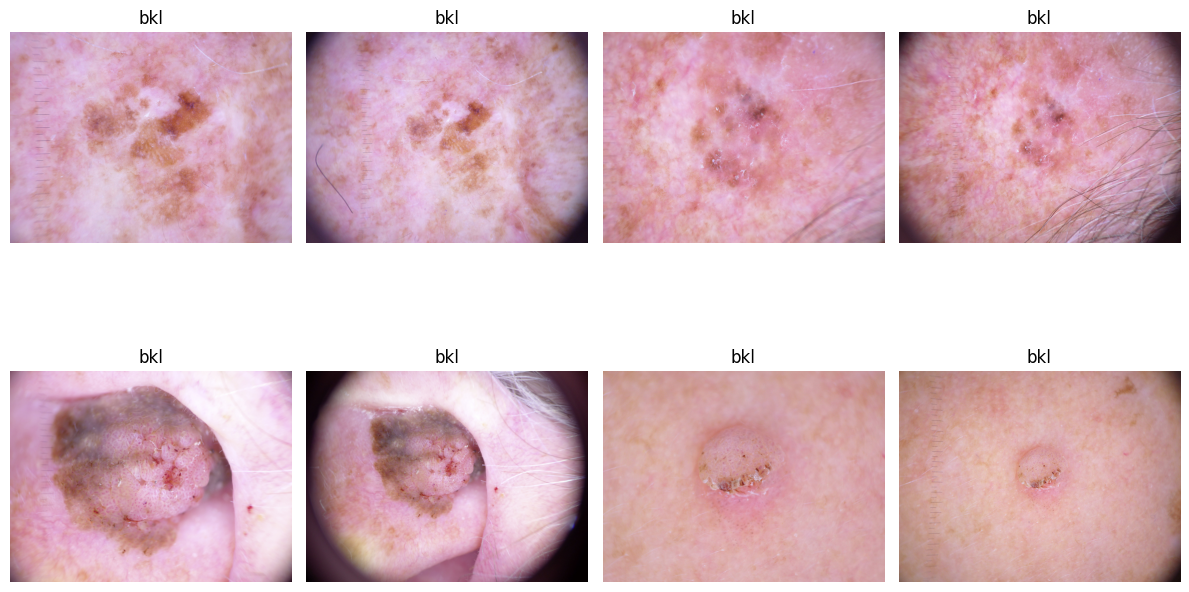

In [ ]:
plt.figure(figsize=(12, 8))

number_of_images = min(8, len(metadata))

for i in range(number_of_images):

    row = metadata.iloc[i]

    image = Image.open(row["image_path"])

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(row["dx"])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Split the dataset

We use:

- 80% for training
- 20% for testing

In [ ]:
train_df, test_df = train_test_split(
    metadata,
    test_size=0.20,
    random_state=42,
    stratify=metadata["dx"]
)

print("Training images:", len(train_df))
print("Testing images:", len(test_df))

Training images: 8012
Testing images: 2003


## 8. Convert class names to numbers

In [ ]:
classes = sorted(metadata["dx"].unique())

class_to_number = {
    name: i for i, name in enumerate(classes)
}

print("Classes:", classes)
print("Class mapping:", class_to_number)

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


## 9. Create TensorFlow datasets

Images are resized to 224 × 224 for EfficientNetB0.

In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    label = tf.one_hot(
        label,
        depth=len(classes)
    )

    return image, label


def create_dataset(dataframe, shuffle=False):

    image_paths = dataframe["image_path"].values

    labels = dataframe["dx"].map(
        class_to_number
    ).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            len(dataframe),
            seed=42
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


train_dataset = create_dataset(
    train_df,
    shuffle=True
)

test_dataset = create_dataset(
    test_df
)

print("Datasets created successfully.")

Datasets created successfully.


## 10. Load the pre-trained EfficientNetB0

EfficientNetB0 has already learned image features from ImageNet.

We freeze it and use it as a feature extractor.

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("EfficientNetB0 loaded.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 loaded.


## 11. Build a simple model

**Input → EfficientNetB0 → Pooling → Dense → Output**

In [ ]:
model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.2),

    layers.Dense(
        len(classes),
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,442 (16.08 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 12. Compile the model

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")

Model compiled.


## 13. Train the model

We use only 5 epochs to keep this project simple.

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 801s 3s/step - accuracy: 0.8179 - loss: 0.5018 - val_accuracy: 0.8013 - val_loss: 0.5513
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 876s 3s/step - accuracy: 0.8258 - loss: 0.4705 - val_accuracy: 0.8093 - val_loss: 0.5451
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 804s 3s/step - accuracy: 0.8359 - loss: 0.4497 - val_accuracy: 0.8183 - val_loss: 0.5289
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 871s 3s/step - accuracy: 0.8421 - loss: 0.4291 - val_accuracy: 0.8208 - val_loss: 0.5175
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 848s 3s/step - accuracy: 0.8552 - loss: 0.3972 - val_accuracy: 0.8268 - val_loss: 0.5040


## 14. Accuracy graph

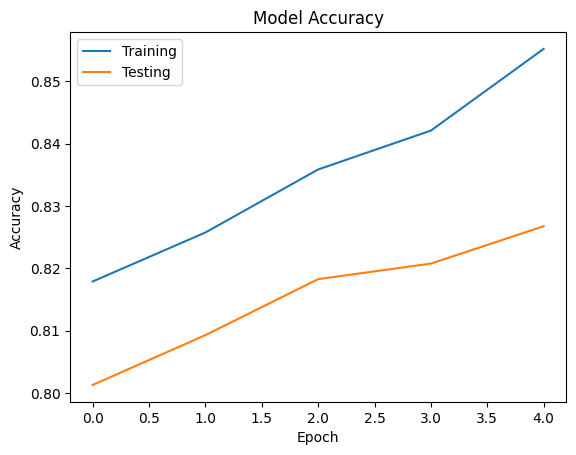

In [ ]:
plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Testing"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.legend()
plt.show()

## 15. Test the model

In [ ]:
loss, accuracy = model.evaluate(
    test_dataset
)

print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.8268 - loss: 0.5040
Test Accuracy: 0.8267598748207092


## 16. Confusion Matrix

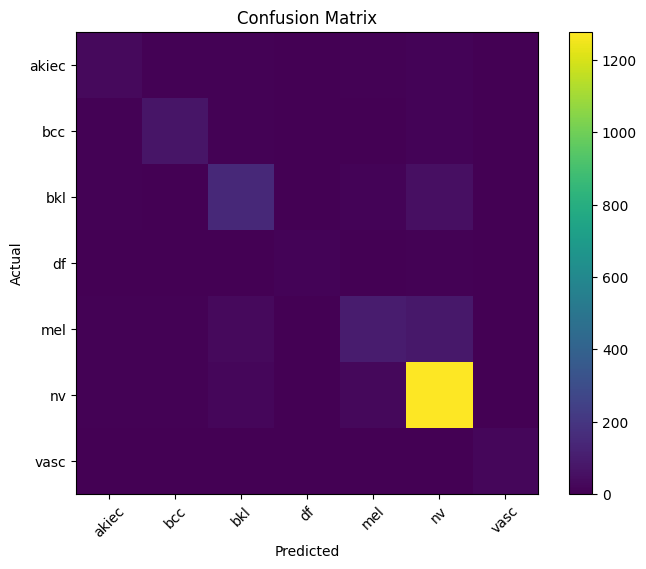

In [ ]:
true_labels = []
predicted_labels = []

for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    true_labels.extend(
        np.argmax(
            labels.numpy(),
            axis=1
        )
    )

    predicted_labels.extend(
        np.argmax(
            predictions,
            axis=1
        )
    )

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.show()

## 17. Classification Report

In [ ]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=classes
    )
)

              precision    recall  f1-score   support

       akiec       0.57      0.51      0.54        65
         bcc       0.73      0.70      0.71       103
         bkl       0.68      0.66      0.67       220
          df       0.67      0.43      0.53        23
         mel       0.64      0.43      0.51       223
          nv       0.89      0.95      0.92      1341
        vasc       0.88      0.82      0.85        28

    accuracy                           0.83      2003
   macro avg       0.72      0.64      0.68      2003
weighted avg       0.81      0.83      0.82      2003



## 18. Predict one image

This follows the simple pipeline:

**Input → EfficientNetB0 → Inference → Processing → Output**

In [ ]:
def predict_image(image_path):

    # Input image
    image = Image.open(
        image_path
    ).convert("RGB")

    # Resize
    resized_image = image.resize(
        IMAGE_SIZE
    )

    # Convert to NumPy
    image_array = np.array(
        resized_image
    )

    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # Inference
    prediction = model.predict(
        image_array,
        verbose=0
    )[0]

    # Processing
    index = np.argmax(prediction)

    predicted_class = classes[index]

    confidence = prediction[index]

    # Output
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Predicted Class: {predicted_class}\n"
        f"Confidence: {confidence:.2%}"
    )

    plt.show()

    print("Predicted class:", predicted_class)
    print("Confidence:", f"{confidence:.2%}")

    return predicted_class, confidence

## 19. Test a single image

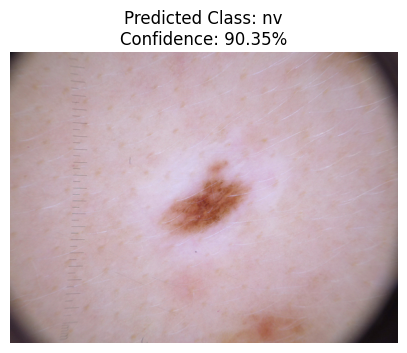

Predicted class: nv
Confidence: 90.35%


('nv', np.float32(0.9035182))

In [ ]:
sample_image = test_df.iloc[0]["image_path"]

predict_image(sample_image)

## 20. Save the model

In [ ]:
model.save(
    "skin_lesion_efficientnetb0.keras"
)

print("Model saved successfully.")

Model saved successfully.


## 21. Simple application use case

The trained model can be connected to a simple web application.

```text
User uploads image
        ↓
Resize image
        ↓
EfficientNetB0
        ↓
Prediction
        ↓
Find predicted class
        ↓
Display result
```

Example:

```text
Predicted class: nv
Confidence: 85%

Educational classification result only.
Not a clinical diagnosis.
```

## 22. Conclusion

In this project we used:

- HAM10000 dataset
- Basic image preprocessing
- Pre-trained EfficientNetB0
- Transfer learning
- Simple classification
- Accuracy
- Confusion matrix
- Classification report
- Single-image prediction

### Final pipeline

**Input → Pre-trained EfficientNetB0 → Inference → Processing → Output → Application**

> This is an educational image-classification project and is not a clinical diagnostic system.

## References

- HAM10000 dataset — Tschandl, Rosendahl & Kittler, Scientific Data (2018).
- EfficientNet — Tan & Le, ICML (2019).
- TensorFlow / Keras EfficientNetB0.

## Streamlit Deployment — VS Code

After training the model, run the following cells to:
1. Save the trained EfficientNetB0 model.
2. Create `app.py` for Streamlit.
3. Create `requirements.txt`.

Then use the VS Code terminal:

```bash
pip install -r requirements.txt
streamlit run app.py
```


In [ ]:
# Save the trained model for Streamlit
MODEL_PATH = "skin_lesion_efficientnetb0.keras"

model.save(MODEL_PATH)

print(f"Model saved successfully: {MODEL_PATH}")


In [ ]:
# Create the Streamlit application
from pathlib import Path

streamlit_app = r"""
import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image

st.set_page_config(
    page_title="Skin Lesion Classifier",
    page_icon="🩺",
    layout="centered"
)

st.title("🩺 Skin Lesion Classifier")
st.caption("EfficientNetB0 • HAM10000")
st.warning(
    "Educational/research use only. "
    "This application is not a medical diagnosis tool."
)

MODEL_PATH = "skin_lesion_efficientnetb0.keras"
IMAGE_SIZE = (224, 224)

# Same class ordering used by the notebook:
# sorted(metadata["dx"].unique())
CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)

try:
    model = load_model()
except Exception as e:
    st.error(f"Could not load model: {e}")
    st.stop()

uploaded_file = st.file_uploader(
    "Upload a skin-lesion image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded image",
        width="stretch"
    )

    if st.button("🔍 Predict", type="primary", use_container_width=True):

        # EfficientNetB0 input
        image_resized = image.resize(IMAGE_SIZE)
        image_array = np.asarray(
            image_resized,
            dtype=np.float32
        )
        image_array = np.expand_dims(
            image_array,
            axis=0
        )

        predictions = model.predict(
            image_array,
            verbose=0
        )[0]

        predicted_index = int(np.argmax(predictions))
        predicted_class = CLASS_NAMES[predicted_index]
        confidence = float(predictions[predicted_index])

        st.subheader("Prediction")
        st.success(
            f"Predicted class: {predicted_class}"
        )
        st.metric(
            "Confidence",
            f"{confidence:.2%}"
        )

        st.subheader("Class probabilities")

        for name, probability in zip(
            CLASS_NAMES,
            predictions
        ):
            st.write(
                f"**{name}** — {probability:.2%}"
            )
            st.progress(
                float(probability)
            )

st.divider()
st.caption(
    "Model: EfficientNetB0 trained from the supplied notebook. "
    "Predictions should not be interpreted as a clinical diagnosis."
)
"""

Path("app.py").write_text(
    streamlit_app,
    encoding="utf-8"
)

print("app.py created successfully.")
print("Run: streamlit run app.py")


In [ ]:
# Create requirements.txt for VS Code / Streamlit
from pathlib import Path

requirements = """streamlit>=1.40,<2
tensorflow>=2.16,<3
numpy>=1.26,<3
pillow>=10,<12
"""

Path("requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

print("requirements.txt created successfully.")
